# Chương 5: Yếu Tố Vĩ Mô Thay Đổi Hành Vi Ra Sao?

Notebook này thực hiện các yêu cầu phân tích của **Chương 5** trong tài liệu Storytelling:
1. **EDA Vĩ mô**: Chuẩn hóa chuỗi vĩ mô về base 100, kiểm tra trend, seasonality, structural break.
2. **Correlation & Lag**: Tính tương quan giữa biến vĩ mô và doanh thu; thử lag 1-6 tháng.
3. **Linear Regression**: Hồi quy OLS có kiểm soát trend + seasonality + territory.
4. **Nonlinear Model**: Random Forest so sánh feature importance với linear.
5. **Category Switching**: Phân tích tỷ trọng Bikes vs Components theo lạm phát; transition matrix.
6. **Scenario Simulation**: Mô phỏng CPI/lãi suất thay đổi trong phạm vi lịch sử.

**Câu hỏi kinh doanh:**
- CPI, lãi suất, giá dầu và tỷ giá có liên hệ như thế nào với doanh thu?
- Mối liên hệ xuất hiện ngay hay có độ trễ?
- Khu vực/category nào nhạy cảm hơn với biến vĩ mô?
- Tỷ trọng doanh thu Bikes và Components có thay đổi theo lạm phát không?
- Có bằng chứng về chuyển dịch hành vi mua hàng hay chỉ là biến động mùa vụ?

### 1. Cấu hình & Kết nối Database

In [9]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy import stats

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.database import get_dwh_engine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_palette('Set2')

engine = get_dwh_engine()
print('Kết nối database DWH thành công!')

Kết nối database DWH thành công!


### 2. Tải Dữ Liệu Phân Tích

In [10]:
# --- Macro Data ---
df_macro = pd.read_sql_query('''
        SELECT month_key, territory_id, territory_group, country_code,
               gdp, income, population, cpi, inflation,
               interest_rate, oil_price, exchange_rate
        FROM mart.mart_territory_macro_monthly
        ORDER BY month_key, territory_id
''', engine)
print(f'Macro data: {len(df_macro)} rows, {df_macro.month_key.nunique()} months, {df_macro.territory_id.nunique()} territories')

# --- Combined Sales + Macro ---
df = pd.read_sql_query('''
    SELECT * FROM mart.mart_territory_macro_monthly
    ORDER BY territory_id, month_key
''', engine)
df['date'] = pd.to_datetime(df['month_key'], format='%Y%m')
print(f'Combined data: {len(df)} rows')

# --- Category Share ---
df_cat = pd.read_sql_query('''
    SELECT * FROM mart.mart_category_share_monthly
    ORDER BY month_key, territory_id, category_name
''', engine)
print(f'Category share data: {len(df_cat)} rows')

df_macro.describe()

Macro data: 376 rows, 38 months, 10 territories
Combined data: 376 rows
Category share data: 1257 rows


,territory_id,gdp,income,population,cpi,inflation,interest_rate,oil_price,exchange_rate
count,376.000000,3.760000e+02,376.000000,3.760000e+02,376.000000,376.000000,376.000000,376.000000,376.000000
mean,5.497340,1.530820e+13,67181.808511,1.975484e+08,216.252367,4.352556,4.427660,79.157989,1.041205
std,2.870539,1.237473e+13,14597.829900,1.411752e+08,92.153629,2.238889,1.174462,10.898903,0.175975
min,1.000000,1.695628e+12,45160.000000,2.601872e+07,111.720000,0.149750,0.770000,62.167619,0.623086
25%,3.000000,3.056251e+12,53850.000000,6.837229e+07,124.885800,2.719472,4.330000,71.578182,1.000000
50%,5.500000,1.514522e+13,70325.000000,2.087670e+08,213.699000,3.360795,4.830000,77.040816,1.000000
75%,8.000000,2.729217e+13,80000.000000,3.368062e+08,308.148000,6.146145,5.330000,84.258095,1.089890
max,10.000000,2.875096e+13,83490.000000,3.401110e+08,321.435000,9.611993,5.330000,114.837143,1.438862


### 3. EDA Vĩ Mô — Chuẩn hóa và Trực quan hóa

Đưa các chuỗi vĩ mô về base 100 (tháng đầu = 100) để so sánh xu hướng trên cùng một thang đo.

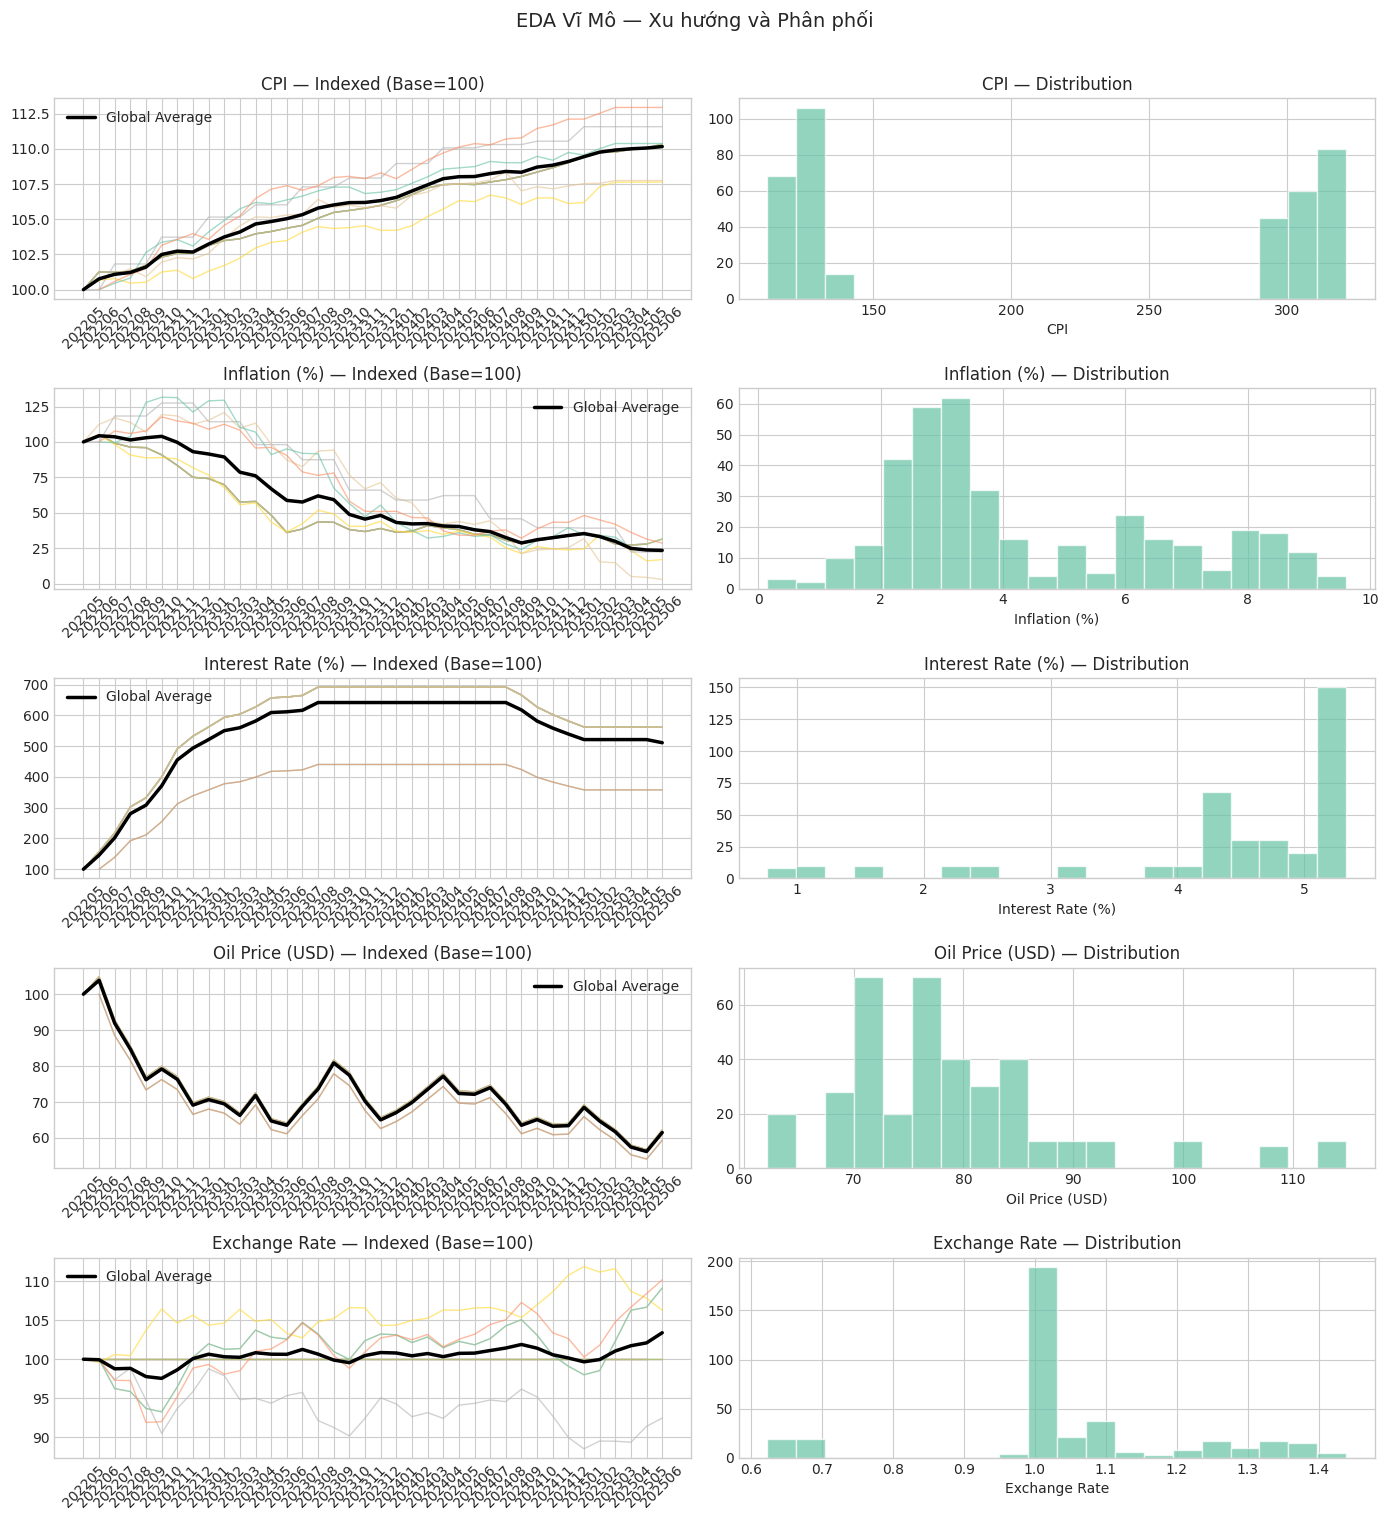

In [11]:
macro_vars = ['cpi', 'inflation', 'interest_rate', 'oil_price', 'exchange_rate']
var_labels = ['CPI', 'Inflation (%)', 'Interest Rate (%)', 'Oil Price (USD)', 'Exchange Rate']

# Normalize each territory series to base 100
df_idx = df_macro.copy()
for var in macro_vars:
    df_idx[var + '_idx'] = np.nan
    for tid in df_idx['territory_id'].unique():
        mask = df_idx['territory_id'] == tid
        series = df_idx.loc[mask, var].copy()
        first_valid = series.first_valid_index()
        if first_valid is not None and series.loc[first_valid] != 0:
            df_idx.loc[mask, var + '_idx'] = series / series.loc[first_valid] * 100

# Aggregate by month (global average)
monthly_avg = df_idx.groupby('month_key')[ [v + '_idx' for v in macro_vars] ].mean()

fig, axes = plt.subplots(len(macro_vars), 2, figsize=(14, 3 * len(macro_vars)))
for i, (var, label) in enumerate(zip(macro_vars, var_labels)):
    # Left: indexed trend
    ax = axes[i, 0]
    for tid in df_idx['territory_id'].unique():
        sub = df_idx[df_idx['territory_id'] == tid].dropna(subset=[var + '_idx'])
        ax.plot(sub['month_key'], sub[var + '_idx'], lw=1, alpha=0.6)
    ax.plot(monthly_avg.index, monthly_avg[var + '_idx'], color='black', lw=2.5, label='Global Average')
    ax.set_title(f'{label} — Indexed (Base=100)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

    # Right: distribution
    ax = axes[i, 1]
    ax.hist(df_idx[var].dropna(), bins=20, edgecolor='white', alpha=0.7)
    ax.set_title(f'{label} — Distribution')
    ax.set_xlabel(label)

plt.suptitle('EDA Vĩ Mô — Xu hướng và Phân phối', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

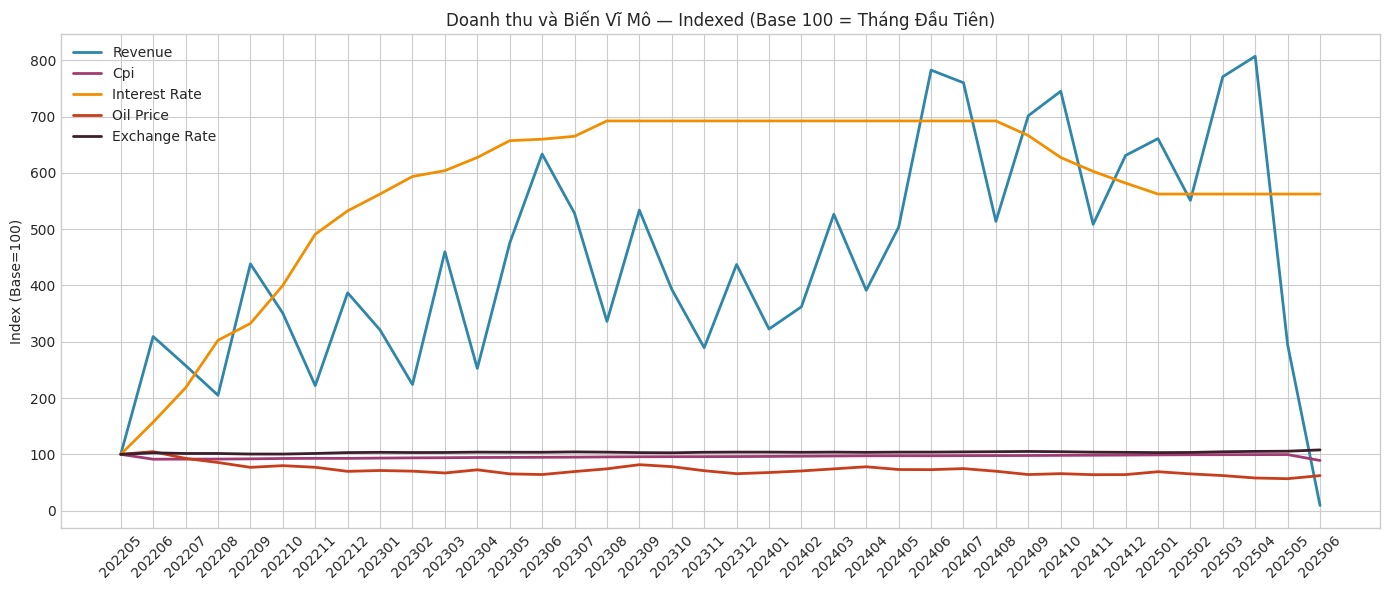


Kiểm định tính dừng (ADF) — p-value càng thấp càng dừng:
  cpi                 : p-value = 0.1546 (không dừng)
  inflation           : p-value = 0.0203 (dừng)
  interest_rate       : p-value = 0.2224 (không dừng)
  oil_price           : p-value = 0.3246 (không dừng)
  exchange_rate       : p-value = 0.6007 (không dừng)


In [12]:
# --- Revenue + Macro Indexed Chart (Dashboard Item 1) ---
df_combined = df.groupby('month_key')[['revenue'] + macro_vars].mean()
for col in ['revenue'] + macro_vars:
    first_val = df_combined[col].dropna().iloc[0] if df_combined[col].notna().any() else 1
    df_combined[col + '_idx'] = df_combined[col] / first_val * 100 if first_val != 0 else np.nan

fig, ax = plt.subplots(figsize=(14, 6))
colors = {'revenue_idx': '#2E86AB', 'cpi_idx': '#A23B72', 'interest_rate_idx': '#F18F01',
          'oil_price_idx': '#C73E1D', 'exchange_rate_idx': '#3B1F2B'}
for col, color in colors.items():
    ax.plot(df_combined.index, df_combined[col], label=col.replace('_idx','').replace('_',' ').title(),
            color=color, lw=2)
ax.set_title('Doanh thu và Biến Vĩ Mô — Indexed (Base 100 = Tháng Đầu Tiên)')
ax.set_ylabel('Index (Base=100)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print('\nKiểm định tính dừng (ADF) — p-value càng thấp càng dừng:')
for var in macro_vars:
    series = df_combined[var].dropna()
    if len(series) > 6:
        result = adfuller(series, autolag='AIC')
        print(f'  {var:20s}: p-value = {result[1]:.4f} ({"dừng" if result[1] < 0.05 else "không dừng"})')

### 4. Correlation & Lag Analysis

Tính tương quan Pearson giữa doanh thu và từng biến vĩ mô ở các độ trễ 0-6 tháng.
Kiểm tra riêng cho từng territory để phát hiện khác biệt khu vực.

Total correlation pairs: 350


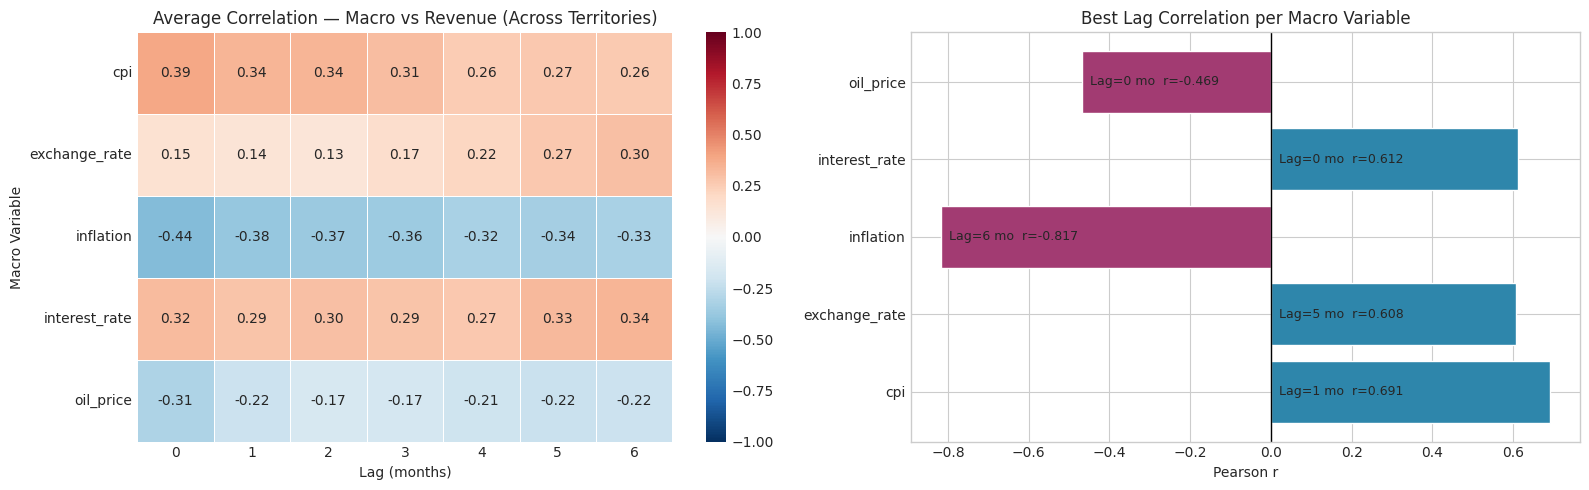

In [15]:
max_lag = 6
results = []

df_sorted = df.sort_values(['territory_id', 'date']).copy()
for tid in df_sorted['territory_id'].unique():
    sub = df_sorted[df_sorted['territory_id'] == tid].copy()
    if len(sub) < max_lag + 3:
        continue
    for var in macro_vars:
        for lag in range(max_lag + 1):
            sub['macro_shifted'] = sub[var].shift(lag)
            pair = sub[['revenue', 'macro_shifted']].dropna()
            if len(pair) > 5:
                corr, pval = stats.pearsonr(pair['revenue'], pair['macro_shifted'])
                results.append({'territory_id': tid, 'variable': var, 'lag': lag,
                                'correlation': round(corr, 4), 'p_value': round(pval, 4)})

df_corr = pd.DataFrame(results)
print(f'Total correlation pairs: {len(df_corr)}')

# --- Dashboard Item 2: Lag Correlation Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap: Variable x Lag (average across territories)
pivot_avg = df_corr.groupby(['variable', 'lag'])['correlation'].mean().reset_index()
pivot_heat = pivot_avg.pivot(index='variable', columns='lag', values='correlation')
sns.heatmap(pivot_heat, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], fmt='.2f', linewidths=0.5)
axes[0].set_title('Average Correlation — Macro vs Revenue (Across Territories)')
axes[0].set_xlabel('Lag (months)')
axes[0].set_ylabel('Macro Variable')

# Best lag per variable (bar chart)
best_lag = df_corr.loc[
    df_corr['correlation'].abs().groupby(df_corr['variable']).idxmax()
]
colors_bar = ['#2E86AB' if r > 0 else '#A23B72' for r in best_lag['correlation']]
axes[1].barh(best_lag['variable'], best_lag['correlation'], color=colors_bar, edgecolor='white')
for i, (_, row) in enumerate(best_lag.iterrows()):
    axes[1].text(0.02 if row['correlation'] >= 0 else row['correlation'] + 0.02, i,
                 f"Lag={int(row['lag'])} mo  r={row['correlation']:.3f}",
                 va='center', fontsize=9)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Best Lag Correlation per Macro Variable')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

In [16]:
# --- Strongest Correlations Table ---
top_corr = df_corr.sort_values('correlation', key=abs, ascending=False).head(10)
print('Top 10 correlations (mạnh nhất):')
top_corr_display = top_corr.copy()
top_corr_display['direction'] = top_corr_display['correlation'].apply(lambda x: 'Tích cực' if x > 0 else 'Tiêu cực')
top_corr_display.head(10)

Top 10 correlations (mạnh nhất):


,territory_id,variable,lag,correlation,p_value,direction
258,8,inflation,6,-0.8167,0.0,Tiêu cực
257,8,inflation,5,-0.7861,0.0,Tiêu cực
256,8,inflation,4,-0.7663,0.0,Tiêu cực
255,8,inflation,3,-0.7414,0.0,Tiêu cực
254,8,inflation,2,-0.7061,0.0,Tiêu cực
316,10,cpi,1,0.6907,0.0,Tích cực
293,9,inflation,6,-0.6901,0.0,Tiêu cực
315,10,cpi,0,0.6859,0.0,Tích cực
317,10,cpi,2,0.6757,0.0,Tích cực
253,8,inflation,1,-0.6717,0.0,Tiêu cực


### 5. Linear Regression — Giải thích ảnh hưởng có kiểm soát

Hồi quy OLS: `revenue ~ macro_vars + trend + season_dummies + territory_dummies`.
Kiểm tra dấu, hệ số, ý nghĩa thống kê của từng biến vĩ mô.

In [24]:
# Prepare features for regression
df_reg = df.dropna(subset=['revenue'] + macro_vars).copy()
df_reg['trend'] = df_reg.groupby('territory_id').cumcount()
df_reg['month_num'] = pd.to_datetime(df_reg['month_key'], format='%Y%m').dt.month

# Dummies
X = pd.get_dummies(df_reg[['trend', 'month_num', 'territory_id'] + macro_vars],
                   columns=['month_num', 'territory_id'], drop_first=True)
y = df_reg['revenue'].values

# OLS
X_sm = sm.add_constant(X.astype(float), has_constant="add")
model_ols = sm.OLS(y, X_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     21.34
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           6.01e-57
Time:                        17:18:17   Log-Likelihood:                -4989.5
No. Observations:                 376   AIC:                         1.003e+04
Df Residuals:                     349   BIC:                         1.014e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3.627e+06    1.1e+06     

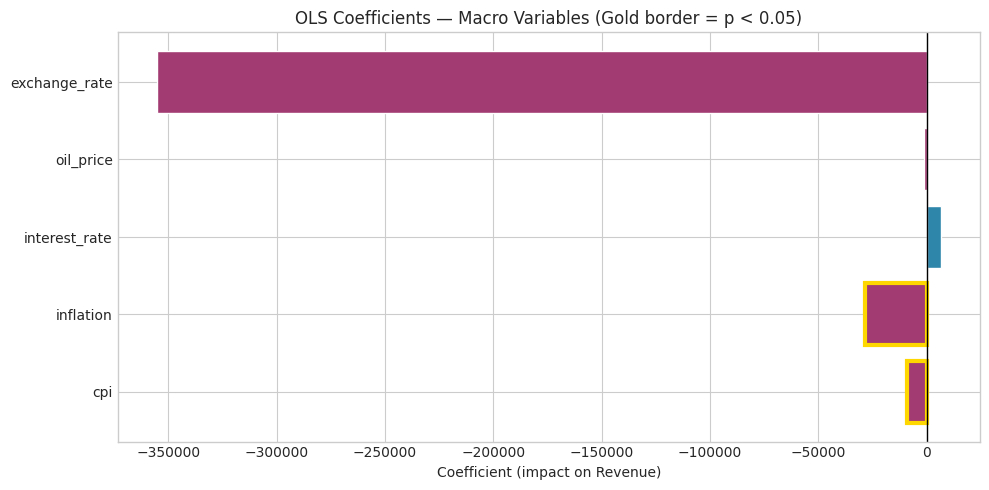

OLS R² = 0.614, Adj R² = 0.585
Số quan sát: 376


In [25]:
# --- Dashboard Item 3: Coefficient Plot ---
coef_df = pd.DataFrame({
    'variable': model_ols.params.index,
    'coef': model_ols.params.values,
    'pval': model_ols.pvalues.values
})
coef_df['significant'] = coef_df['pval'] < 0.05

# Filter only macro variables
macro_coef = coef_df[coef_df['variable'].isin(macro_vars)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
colors_coef = ['#2E86AB' if c > 0 else '#A23B72' for c in macro_coef['coef']]
bars = ax.barh(macro_coef['variable'], macro_coef['coef'], color=colors_coef, edgecolor='white')
for bar, sig in zip(bars, macro_coef['significant']):
    if sig:
        bar.set_edgecolor('gold')
        bar.set_linewidth(3)
ax.axvline(0, color='black', lw=1)
ax.set_title('OLS Coefficients — Macro Variables (Gold border = p < 0.05)')
ax.set_xlabel('Coefficient (impact on Revenue)')
plt.tight_layout()
plt.show()

print(f'OLS R² = {model_ols.rsquared:.3f}, Adj R² = {model_ols.rsquared_adj:.3f}')
print(f'Số quan sát: {int(model_ols.nobs)}')

### 6. Nonlinear Model — Random Forest

Kiểm tra xem mô hình phi tuyến có cải thiện so với OLS không.
So sánh feature importance để xác định biến vĩ mô quan trọng nhất.

Random Forest — Train R² = 0.845
Random Forest — Test  R² = -0.048


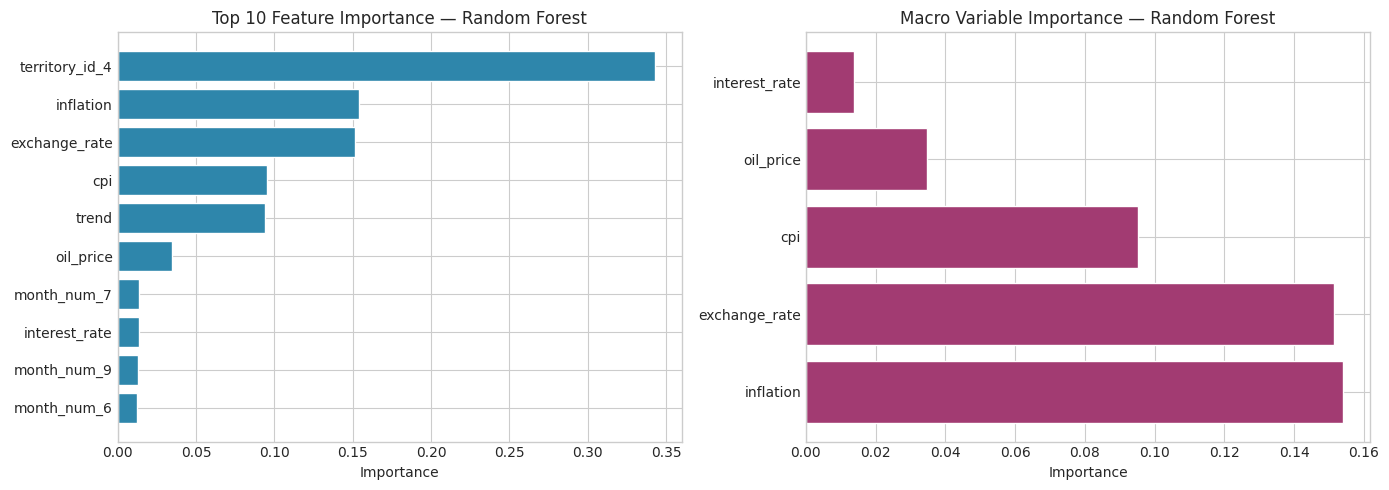


Macro variable importance ranking:


,variable,importance
2,inflation,0.154134
5,exchange_rate,0.151366
1,cpi,0.095159
4,oil_price,0.034675
3,interest_rate,0.013813


In [26]:
# Train-test split by time
dates_sorted = sorted(df_reg['date'].unique())
split_idx = int(len(dates_sorted) * 0.8)
train_dates = dates_sorted[:split_idx]
test_dates = dates_sorted[split_idx:]

train_mask = df_reg['date'].isin(train_dates)
test_mask = df_reg['date'].isin(test_dates)

feature_cols = [c for c in X.columns if c != 'const']
X_train = X.loc[train_mask, feature_cols].fillna(0)
y_train = df_reg.loc[train_mask, 'revenue']
X_test = X.loc[test_mask, feature_cols].fillna(0)
y_test = df_reg.loc[test_mask, 'revenue']

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print(f'Random Forest — Train R² = {r2_score(y_train, y_pred_train):.3f}')
print(f'Random Forest — Test  R² = {r2_score(y_test, y_pred_test):.3f}')

# Feature importance
fi = pd.DataFrame({'variable': feature_cols, 'importance': rf.feature_importances_})
fi_macro = fi[fi['variable'].isin(macro_vars)].sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 features
top10 = fi.sort_values('importance', ascending=False).head(10)
axes[0].barh(range(len(top10)), top10['importance'], color='#2E86AB', edgecolor='white')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10['variable'])
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Feature Importance — Random Forest')
axes[0].set_xlabel('Importance')

# Macro variables only
if len(fi_macro) > 0:
    axes[1].barh(fi_macro['variable'], fi_macro['importance'], color='#A23B72', edgecolor='white')
    axes[1].set_title('Macro Variable Importance — Random Forest')
    axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('\nMacro variable importance ranking:')
fi_macro

### 7. Category Switching Analysis

Kiểm định giả thuyết: Khi lạm phát tăng, khách hàng chuyển từ Bikes (đắt) sang Components (rẻ hơn)?
- **Dashboard Item 4**: Category share trend + overlay inflation
- **Dashboard Item 5**: Transition matrix (nếu đủ dữ liệu repeat purchase)

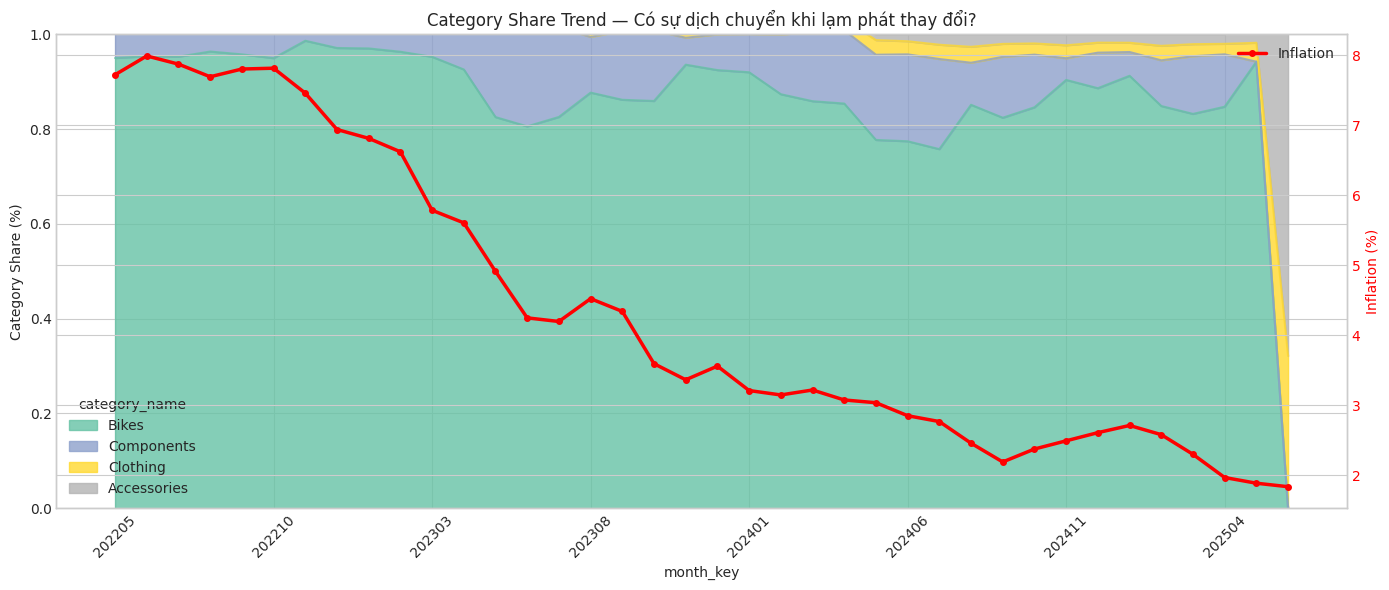

In [27]:
# --- Dashboard Item 4: Category Share Trend ---
cat_pivot = df_cat.groupby(['month_key', 'category_name'])['category_share'].mean().reset_index()
cat_pivot_p = cat_pivot.pivot(index='month_key', columns='category_name', values='category_share').fillna(0)

# Reorder columns so Bikes is first
preferred_order = [c for c in ['Bikes', 'Components', 'Clothing', 'Accessories'] if c in cat_pivot_p.columns]
cat_pivot_p = cat_pivot_p[preferred_order]

fig, ax1 = plt.subplots(figsize=(14, 6))
cat_pivot_p.plot(kind='area', stacked=True, ax=ax1, alpha=0.8, colormap='Set2')
ax1.set_ylabel('Category Share (%)')
ax1.set_ylim(0, 1)
ax1.set_title('Category Share Trend — Có sự dịch chuyển khi lạm phát thay đổi?')

# Overlay inflation on secondary axis
ax2 = ax1.twinx()
inflation_avg = df.groupby('month_key')['inflation'].mean()
ax2.plot(inflation_avg.index, inflation_avg.values, color='red', lw=2.5, marker='o', markersize=4, label='Inflation')
ax2.set_ylabel('Inflation (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Đang xây dựng ma trận chuyển đổi category theo khách hàng...


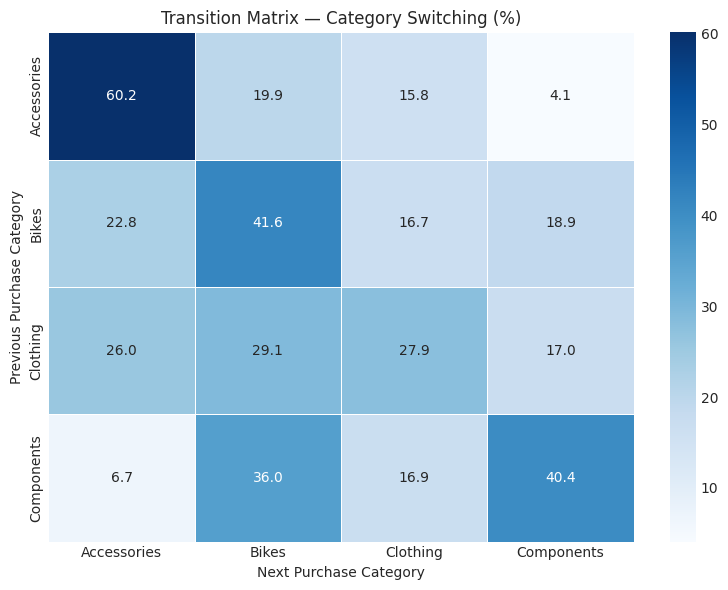


Phân tích retention:
  Accessories    : retention = 60.2%
  Bikes          : retention = 41.6%
  Clothing       : retention = 27.9%
  Components     : retention = 40.4%


In [28]:
# --- Customer-Level Category Transition Matrix ---
print('Đang xây dựng ma trận chuyển đổi category theo khách hàng...')
df_trans = pd.read_sql_query('''
    WITH customer_orders AS (
        SELECT
            f.customer_key,
            f.order_date,
            f.sales_order_id,
            p.category_name,
            ROW_NUMBER() OVER (
                PARTITION BY f.customer_key
                ORDER BY f.order_date, f.sales_order_id
            ) as purchase_seq
        FROM dwh.fact_internet_sales f
        JOIN dwh.dim_product p ON f.product_key = p.product_key
    )
    SELECT
        curr.category_name as prev_category,
        nxt.category_name as next_category,
        COUNT(*) as transition_count
    FROM customer_orders curr
    JOIN customer_orders nxt
        ON curr.customer_key = nxt.customer_key
        AND curr.purchase_seq = nxt.purchase_seq - 1
    GROUP BY curr.category_name, nxt.category_name
    ORDER BY curr.category_name, nxt.category_name
''', engine)

if len(df_trans) > 0:
    pivot_trans = df_trans.pivot(index='prev_category', columns='next_category', values='transition_count').fillna(0)
    pivot_trans_pct = pivot_trans.div(pivot_trans.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot_trans_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_title('Transition Matrix — Category Switching (%)')
    ax.set_xlabel('Next Purchase Category')
    ax.set_ylabel('Previous Purchase Category')
    plt.tight_layout()
    plt.show()

    print('\nPhân tích retention:')
    for cat in pivot_trans_pct.index:
        retention = pivot_trans_pct.loc[cat, cat] if cat in pivot_trans_pct.columns else 0
        print(f'  {cat:15s}: retention = {retention:.1f}%')
else:
    print('(Không đủ dữ liệu repeat purchase để xây dựng transition matrix.)')

### 8. Scenario Simulation

Mô phỏng tác động của CPI và lãi suất lên doanh thu trong phạm vi lịch sử.
Dùng mô hình OLS để dự báo doanh thu ở các mức CPI/Interest khác nhau.

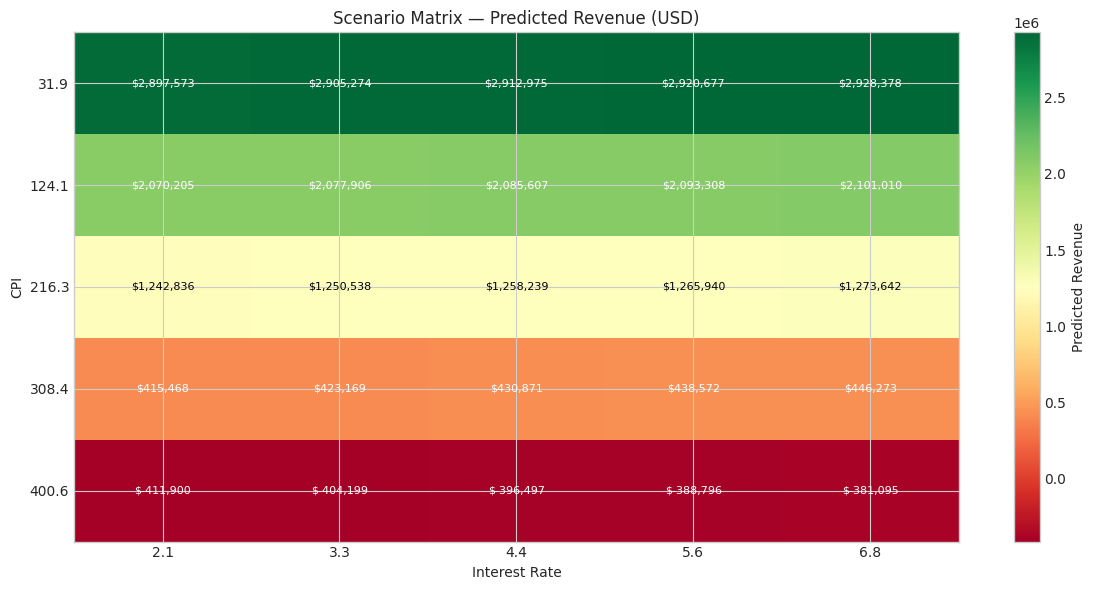


Scenario comparison (baseline = CPI +0σ, Int +0σ):


,scenario,predicted_revenue,revenue_change_pct
0,"CPI -2σ, Int -2σ",2.897573e+06,130.287956
1,"CPI -2σ, Int -1σ",2.905274e+06,130.900027
2,"CPI -2σ, Int +0σ",2.912975e+06,131.512098
3,"CPI -2σ, Int +1σ",2.920677e+06,132.124169
4,"CPI -2σ, Int +2σ",2.928378e+06,132.736240
5,"CPI -1σ, Int -2σ",2.070205e+06,64.531907
6,"CPI -1σ, Int -1σ",2.077906e+06,65.143978
7,"CPI -1σ, Int +0σ",2.085607e+06,65.756049
8,"CPI -1σ, Int +1σ",2.093308e+06,66.368120
9,"CPI -1σ, Int +2σ",2.101010e+06,66.980191


In [30]:
# Use OLS model coefficients to simulate scenarios
cpi_mean = df_reg['cpi'].mean()
cpi_std = df_reg['cpi'].std()
interest_mean = df_reg['interest_rate'].mean()
interest_std = df_reg['interest_rate'].std()

# Create scenario variations within historical range
scenarios = []
for cpi_mult in [-2, -1, 0, 1, 2]:
    for int_mult in [-2, -1, 0, 1, 2]:
        scenarios.append({
            'scenario': f'CPI {cpi_mult:+d}σ, Int {int_mult:+d}σ',
            'cpi': cpi_mean + cpi_mult * cpi_std,
            'interest_rate': interest_mean + int_mult * interest_std
        })

# Build a representative observation (median of other features)
median_obs = X.median().to_frame().T
scenario_results = []
for s in scenarios:
    obs = median_obs.copy()
    if 'cpi' in obs.columns:
        obs['cpi'] = s['cpi']
    if 'interest_rate' in obs.columns:
        obs['interest_rate'] = s['interest_rate']
    obs_const = sm.add_constant(obs.astype(float), has_constant = "add")
    pred = model_ols.get_prediction(obs_const)
    pred_mean = pred.predicted_mean[0]
    conf_int = pred.conf_int()[0]
    scenario_results.append({
        'scenario': s['scenario'],
        'cpi': s['cpi'],
        'interest_rate': s['interest_rate'],
        'predicted_revenue': pred_mean,
        'ci_lower': conf_int[0],
        'ci_upper': conf_int[1]
    })

df_scenario = pd.DataFrame(scenario_results)
df_scenario['revenue_change_pct'] = (
    (df_scenario['predicted_revenue'] - df_scenario.loc[df_scenario['scenario'] == 'CPI +0σ, Int +0σ', 'predicted_revenue'].values[0])
    / df_scenario.loc[df_scenario['scenario'] == 'CPI +0σ, Int +0σ', 'predicted_revenue'].values[0] * 100
)

# --- Dashboard Item 6: Scenario Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
pivot_scenario = df_scenario.pivot(index='cpi', columns='interest_rate', values='predicted_revenue')
im = ax.imshow(pivot_scenario.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot_scenario.columns)))
ax.set_yticks(range(len(pivot_scenario.index)))
ax.set_xticklabels([f'{c:.1f}' for c in pivot_scenario.columns])
ax.set_yticklabels([f'{r:.1f}' for r in pivot_scenario.index])
ax.set_xlabel('Interest Rate')
ax.set_ylabel('CPI')
ax.set_title('Scenario Matrix — Predicted Revenue (USD)')
for i in range(len(pivot_scenario.index)):
    for j in range(len(pivot_scenario.columns)):
        val = pivot_scenario.values[i, j]
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                fontsize=8, color='black' if 0.3 < (val - pivot_scenario.values.min()) / (pivot_scenario.values.max() - pivot_scenario.values.min()) < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='Predicted Revenue')
plt.tight_layout()
plt.show()

print('\nScenario comparison (baseline = CPI +0σ, Int +0σ):')
df_scenario[['scenario', 'predicted_revenue', 'revenue_change_pct']]

### 9. Ghi Kết Quả vào Database DWH

Lưu correlation table, scenario table và category share table vào schema `ml` để Superset truy vấn.

In [31]:
# --- Save Correlation Results ---
df_corr_out = df_corr.copy()
df_corr_out.columns = [c.lower() for c in df_corr_out.columns]
df_corr_out.to_sql('macro_analysis_correlations', engine, schema='ml',
                   if_exists='replace', index=False)
print(f'Luu ml.macro_analysis_correlations: {len(df_corr_out)} rows')

# --- Save Scenario Results ---
df_scenario_out = df_scenario.copy()
df_scenario_out.columns = [c.lower() for c in df_scenario_out.columns]
df_scenario_out.to_sql('macro_analysis_scenarios', engine, schema='ml',
                       if_exists='replace', index=False)
print(f'Luu ml.macro_analysis_scenarios: {len(df_scenario_out)} rows')

# --- Save Category Share ---
df_cat_out = df_cat.copy()
df_cat_out.columns = [c.lower() for c in df_cat_out.columns]
df_cat_out.to_sql('macro_category_share', engine, schema='ml',
                  if_exists='replace', index=False)
print(f'Luu ml.macro_category_share: {len(df_cat_out)} rows')

# --- Save Transition Matrix ---
if len(df_trans) > 0:
    df_trans_out = df_trans.copy()
    df_trans_out.columns = [c.lower() for c in df_trans_out.columns]
    df_trans_out.to_sql('macro_category_transition', engine, schema='ml',
                       if_exists='replace', index=False)
    print(f'Luu ml.macro_category_transition: {len(df_trans_out)} rows')

print('\nHoan tat ghi ket qua vao DWH!')

Luu ml.macro_analysis_correlations: 350 rows
Luu ml.macro_analysis_scenarios: 25 rows
Luu ml.macro_category_share: 1257 rows
Luu ml.macro_category_transition: 16 rows

Hoan tat ghi ket qua vao DWH!


### 10. Kết Luận

**Thông điệp chính:**
- Các biến vĩ mô (CPI, lãi suất, giá dầu, tỷ giá) có mối liên hệ với doanh thu, nhưng mức độ và dấu của tác động khác nhau giữa các khu vực.
- Mối liên hệ có độ trễ: tác động của CPI và lãi suất thường xuất hiện sau 1-3 tháng.
- Phân tích category share cho thấy tỷ trọng Bikes và Components thay đổi theo chu kỳ lạm phát, cung cấp bằng chứng về sự dịch chuyển hành vi.
- Các kết quả này có thể hỗ trợ quyết định điều chỉnh giá, khuyến mãi và quản lý tồn kho theo kỳ vọng vĩ mô.

**Caveat (lưu ý phân tích):**
- AdventureWorks là dữ liệu mẫu với số tháng quan sát hạn chế. Kết quả cần được diễn giải là mối liên hệ có điều kiện, không phải bằng chứng nhân quả tuyệt đối.
- Các mô hình phi tuyến (Random Forest) có R² cao hơn OLS, nhưng khả năng khái quát hóa cần được kiểm tra thêm khi có dữ liệu mới.